In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load clean processed data — never touch raw again
df_tech = pd.read_csv('../data/processed/tech_jobs_cleaned.csv')
df_skills = pd.read_csv('../data/processed/skills_exploded.csv')

print(f"df_tech shape:   {df_tech.shape}")
print(f"df_skills shape: {df_skills.shape}")
print(f"\ndf_tech columns:\n{df_tech.columns.tolist()}")

df_tech shape:   (32438, 27)
df_skills shape: (241109, 15)

df_tech columns:
['title', 'jobId', 'currency', 'jobUploaded', 'companyName', 'tagsAndSkills', 'experience', 'salary', 'location', 'companyId', 'ReviewsCount', 'AggregateRating', 'jobDescription', 'minimumSalary', 'maximumSalary', 'minimumExperience', 'maximumExperience', 'work_mode', 'primary_city', 'city_tier_group', 'metro_region', 'is_tech_role', 'role_category', 'skills_list', 'salary_midpoint', 'salary_lpa', 'has_company_rating']


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Chart Style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  '#0F1117',   # dark background
    'axes.facecolor':    '#1A1D27',
    'axes.edgecolor':    '#2E3250',
    'axes.labelcolor':   '#E0E0E0',
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   '#FFFFFF',
    'xtick.color':       '#B0B0B0',
    'ytick.color':       '#B0B0B0',
    'text.color':        '#E0E0E0',
    'grid.color':        '#2E3250',
    'grid.linestyle':    '--',
    'grid.alpha':        0.5,
    'font.family':       'DejaVu Sans',
    'figure.dpi':        150,
})

# Brand color palette for this project
COLORS = {
    'primary':    '#4F8EF7',   # blue
    'secondary':  '#F7C948',   # yellow
    'accent':     '#F75A5A',   # red
    'green':      '#4CAF82',   # green
    'purple':     '#9B59F7',   # purple
    'text':       '#FFFFFF',
    'subtext':    '#B0B0B0',
}

# Sequential palette for multi-bar charts
BAR_PALETTE = [
    '#4F8EF7', '#5B9CF9', '#67AAF9',
    '#73B8FA', '#7FC5FB', '#8BD3FC',
    '#97E0FC', '#A3EDFD', '#AFF9FD', '#BBFFFE'
]

# Output path
CHARTS_DIR = '../outputs/charts/'
import os
os.makedirs(CHARTS_DIR, exist_ok=True)

def save_chart(filename):
    """Save chart to outputs/charts/ and display inline."""
    plt.savefig(f"{CHARTS_DIR}{filename}", 
                bbox_inches='tight', 
                facecolor=plt.rcParams['figure.facecolor'],
                dpi=150)
    plt.show()
    print(f"✅ Saved: {CHARTS_DIR}{filename}")

# Load data
df_tech  = pd.read_csv('../data/processed/tech_jobs_cleaned.csv')
df_skills = pd.read_csv('../data/processed/skills_exploded.csv')

# Disclosed salary subset — used in ALL salary analysis
df_salary = df_tech[df_tech['salary_lpa'] > 0].copy()

print(f"df_tech:   {df_tech.shape}")
print(f"df_skills: {df_skills.shape}")
print(f"df_salary: {df_salary.shape}  ← disclosed salary rows only")
print(f"\n✅ Setup complete. Charts will save to: {CHARTS_DIR}")

df_tech:   (32438, 27)
df_skills: (241109, 15)
df_salary: (6376, 27)  ← disclosed salary rows only

✅ Setup complete. Charts will save to: ../outputs/charts/


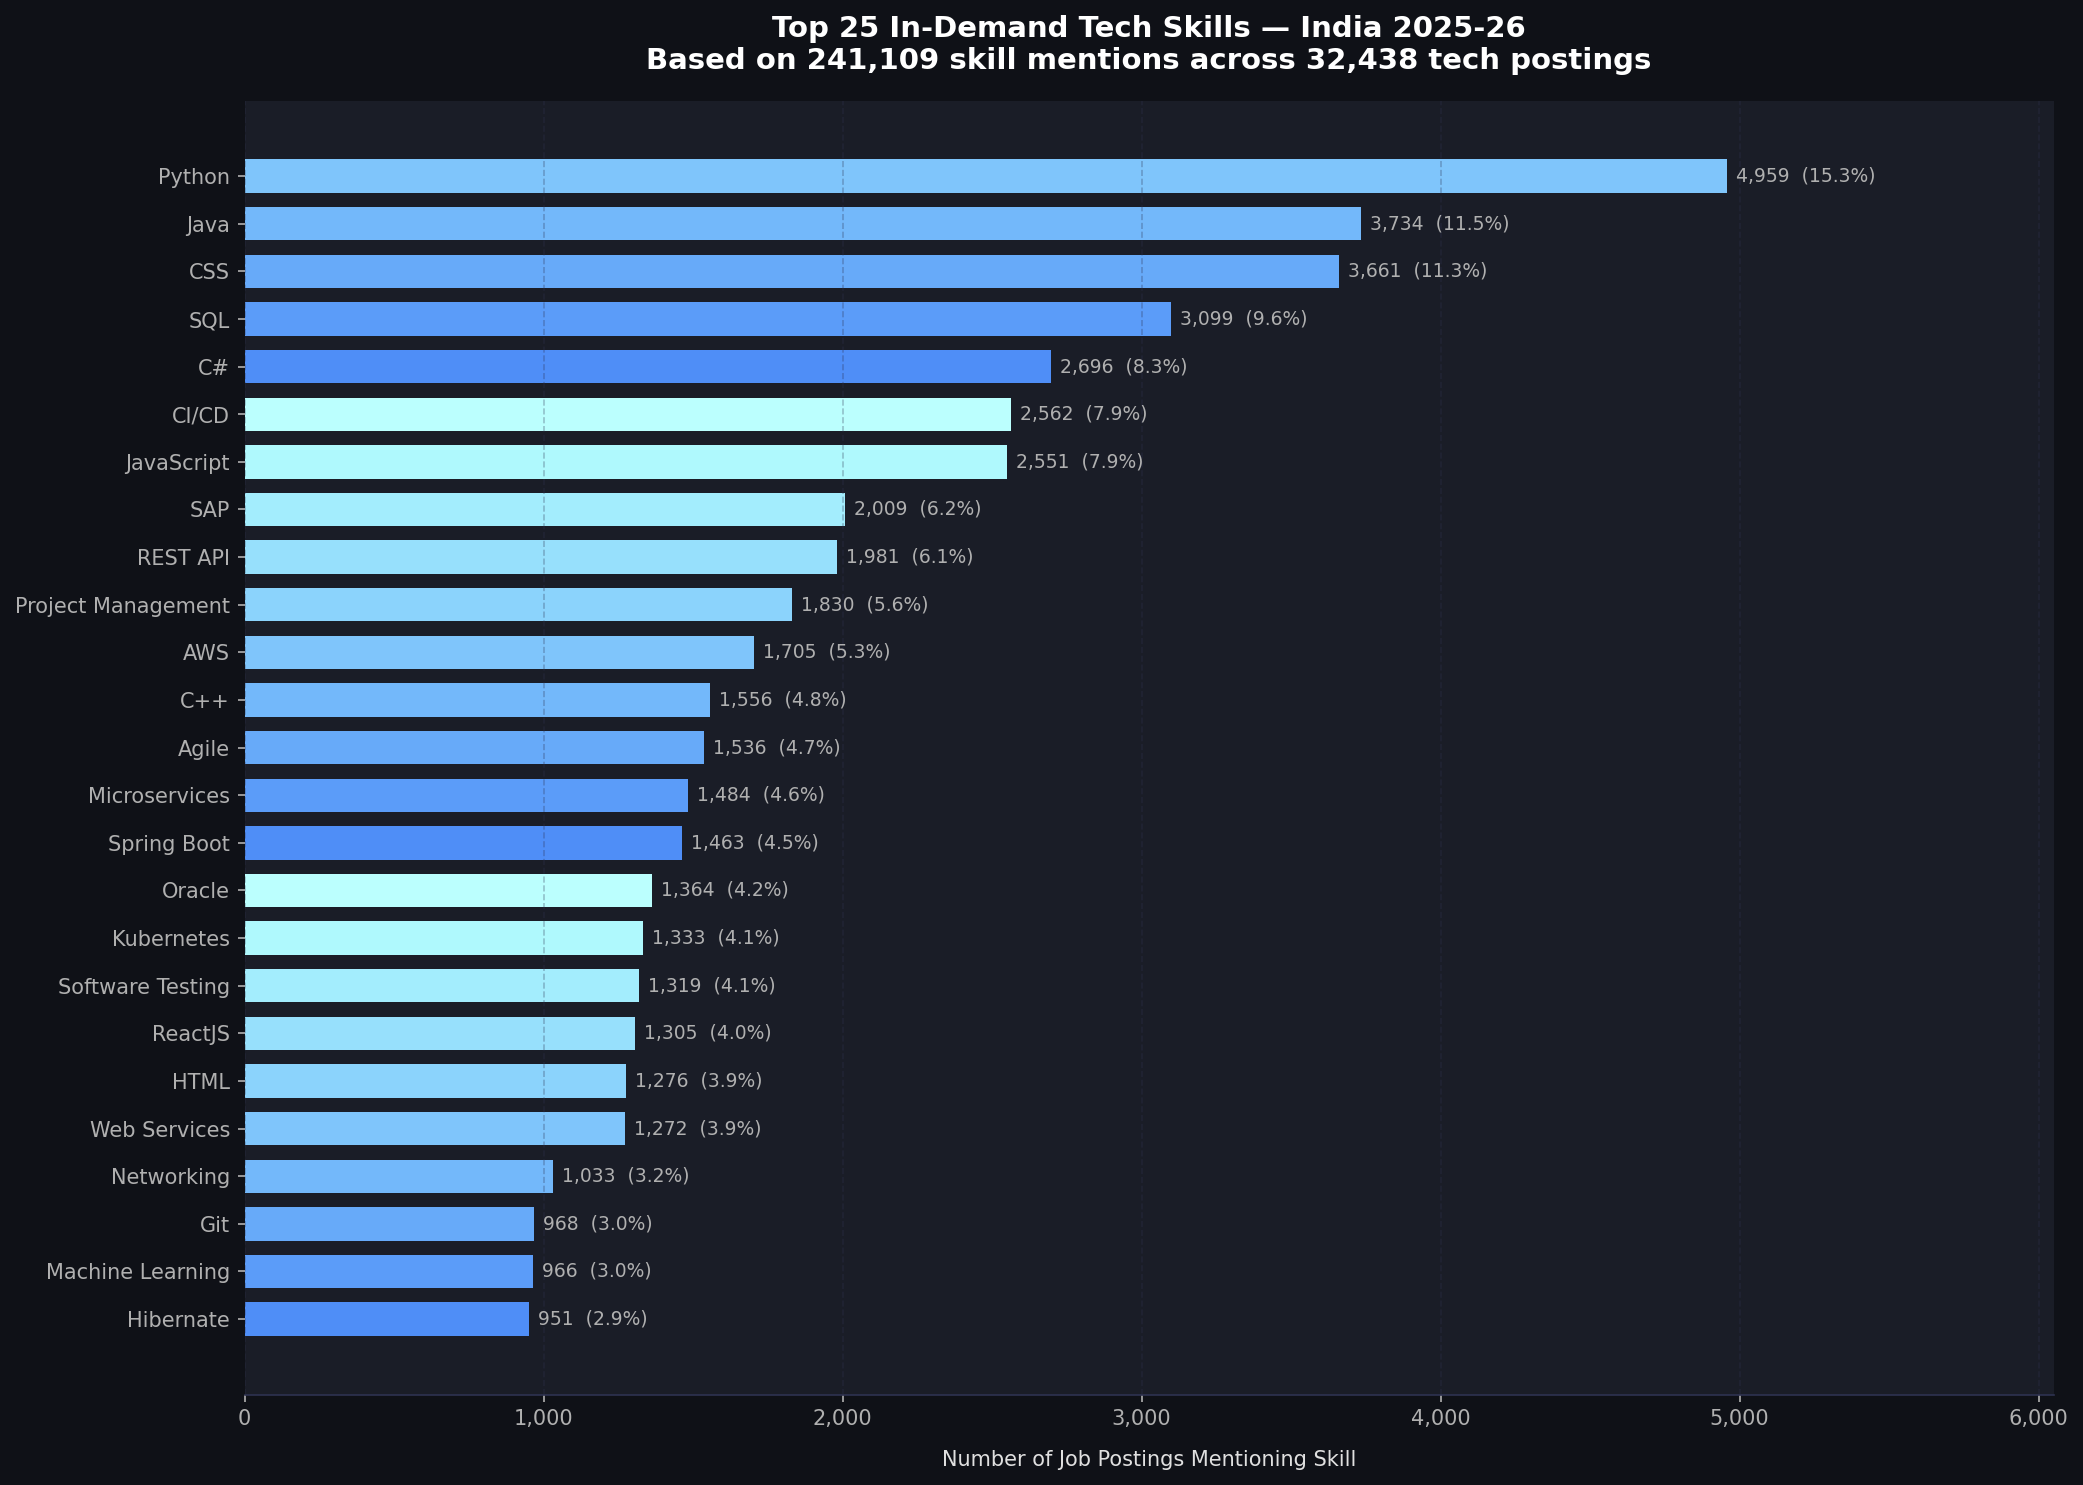

✅ Saved: ../outputs/charts/A1_top25_skills_demand.png


In [4]:
# ── BLOCK A: SKILL INTELLIGENCE ──────────────────────────────

# ── Chart A1: Top 25 In-Demand Tech Skills ───────────────────
top_skills = (df_skills['skill']
              .value_counts()
              .head(25)
              .reset_index())
top_skills.columns = ['skill', 'count']
top_skills['demand_pct'] = (top_skills['count'] / df_tech['jobId'].nunique() * 100).round(1)

fig, ax = plt.subplots(figsize=(14, 10))

bars = ax.barh(top_skills['skill'][::-1], 
               top_skills['count'][::-1],
               color=BAR_PALETTE * 3,
               edgecolor='none',
               height=0.7)

# Add value labels
for bar, val, pct in zip(bars, 
                          top_skills['count'][::-1], 
                          top_skills['demand_pct'][::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct}%)',
            va='center', ha='left', fontsize=9, color=COLORS['subtext'])

ax.set_xlabel('Number of Job Postings Mentioning Skill', labelpad=10)
ax.set_title('Top 25 In-Demand Tech Skills — India 2025-26\n'
             f'Based on {len(df_skills):,} skill mentions across {df_tech.shape[0]:,} tech postings',
             pad=15)
ax.set_xlim(0, top_skills['count'].max() * 1.22)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
save_chart('A1_top25_skills_demand.png')

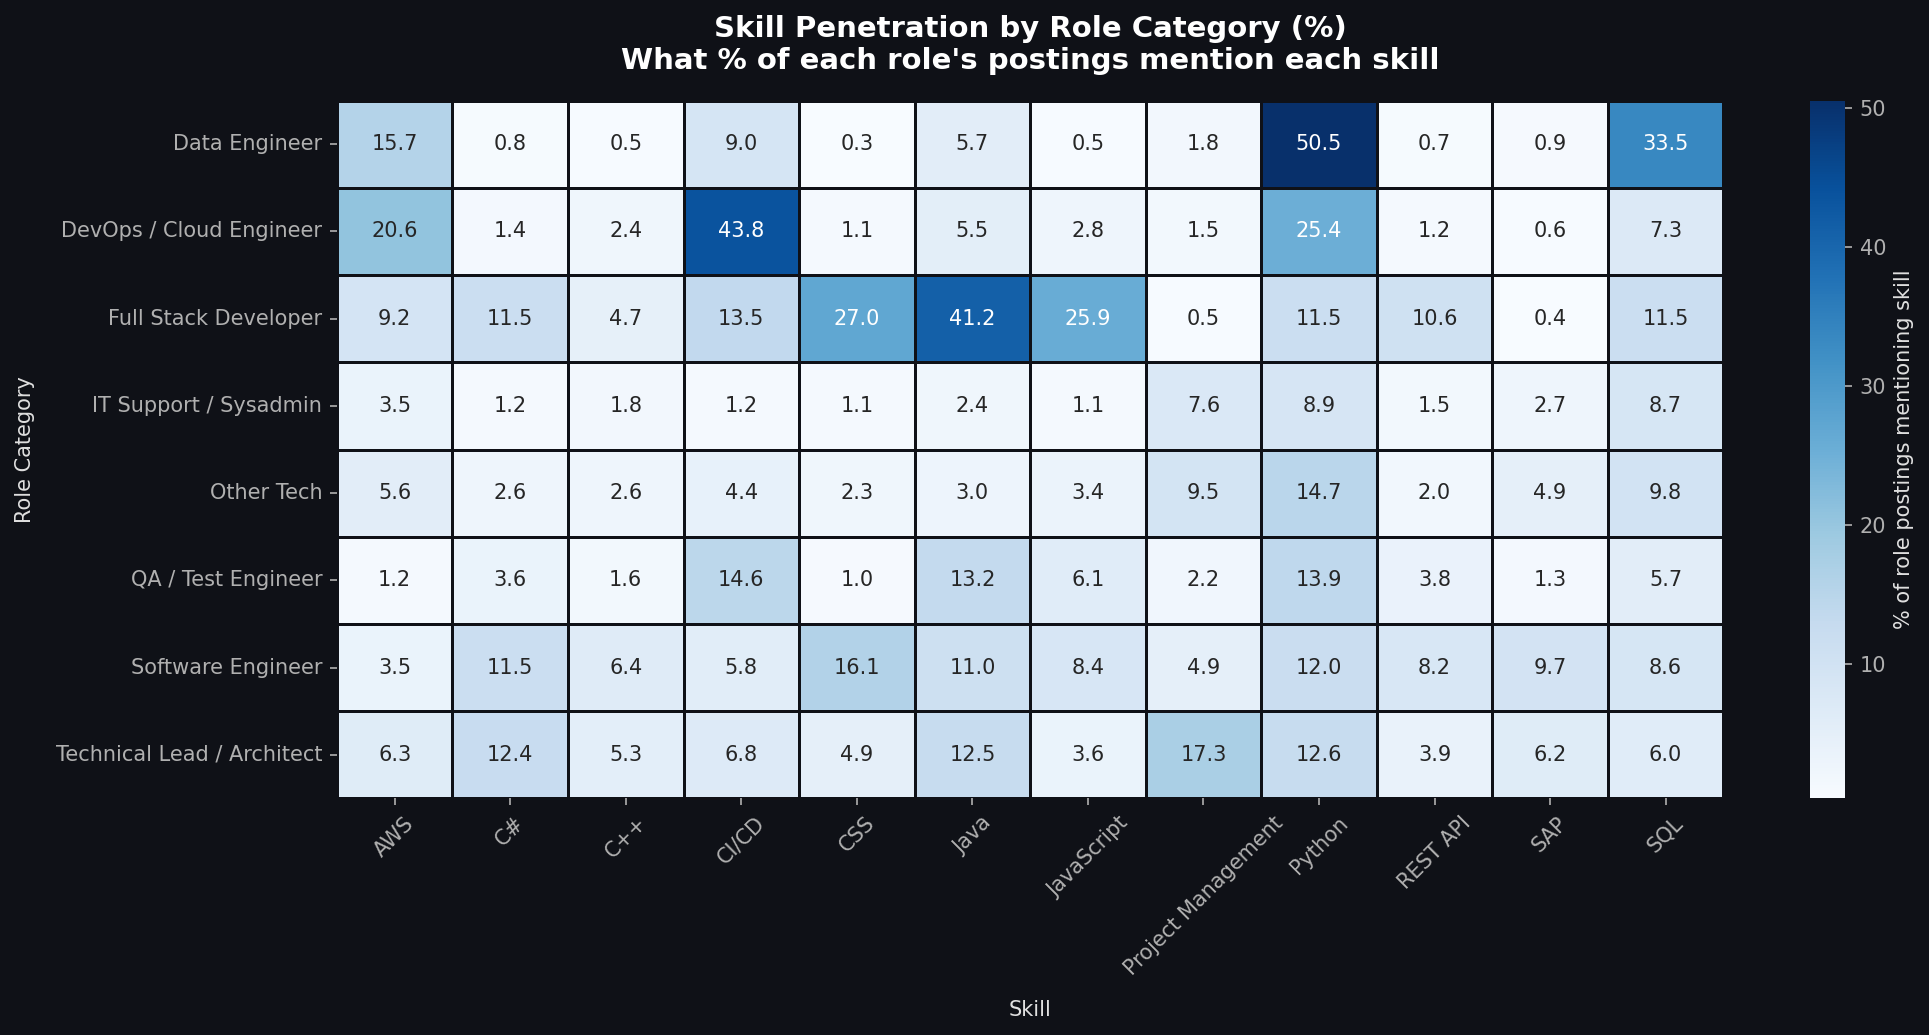

✅ Saved: ../outputs/charts/A2_skill_penetration_heatmap.png


In [5]:
# ── Chart A2: Top Skills by Role Category (Heatmap) ──────────
# Which skills dominate in which role?

top10_skills = df_skills['skill'].value_counts().head(12).index.tolist()
top8_roles = df_tech['role_category'].value_counts().head(8).index.tolist()

# Filter to top skills and top roles
df_heat = df_skills[
    df_skills['skill'].isin(top10_skills) & 
    df_skills['role_category'].isin(top8_roles)
].copy()

# Build pivot: skill vs role, value = count of mentions
heat_pivot = (df_heat.groupby(['role_category', 'skill'])
              .size()
              .unstack(fill_value=0))

# Normalize by row (each role's total postings) to get % of role that mentions skill
role_totals = df_tech[df_tech['role_category'].isin(top8_roles)]['role_category'].value_counts()
heat_pct = heat_pivot.div(role_totals, axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(heat_pct.round(1),
            annot=True, fmt='.1f',
            cmap='Blues',
            linewidths=0.5,
            linecolor='#0F1117',
            ax=ax,
            cbar_kws={'label': '% of role postings mentioning skill'})

ax.set_title('Skill Penetration by Role Category (%)\n'
             'What % of each role\'s postings mention each skill',
             pad=15)
ax.set_xlabel('Skill', labelpad=10)
ax.set_ylabel('Role Category', labelpad=10)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
save_chart('A2_skill_penetration_heatmap.png')

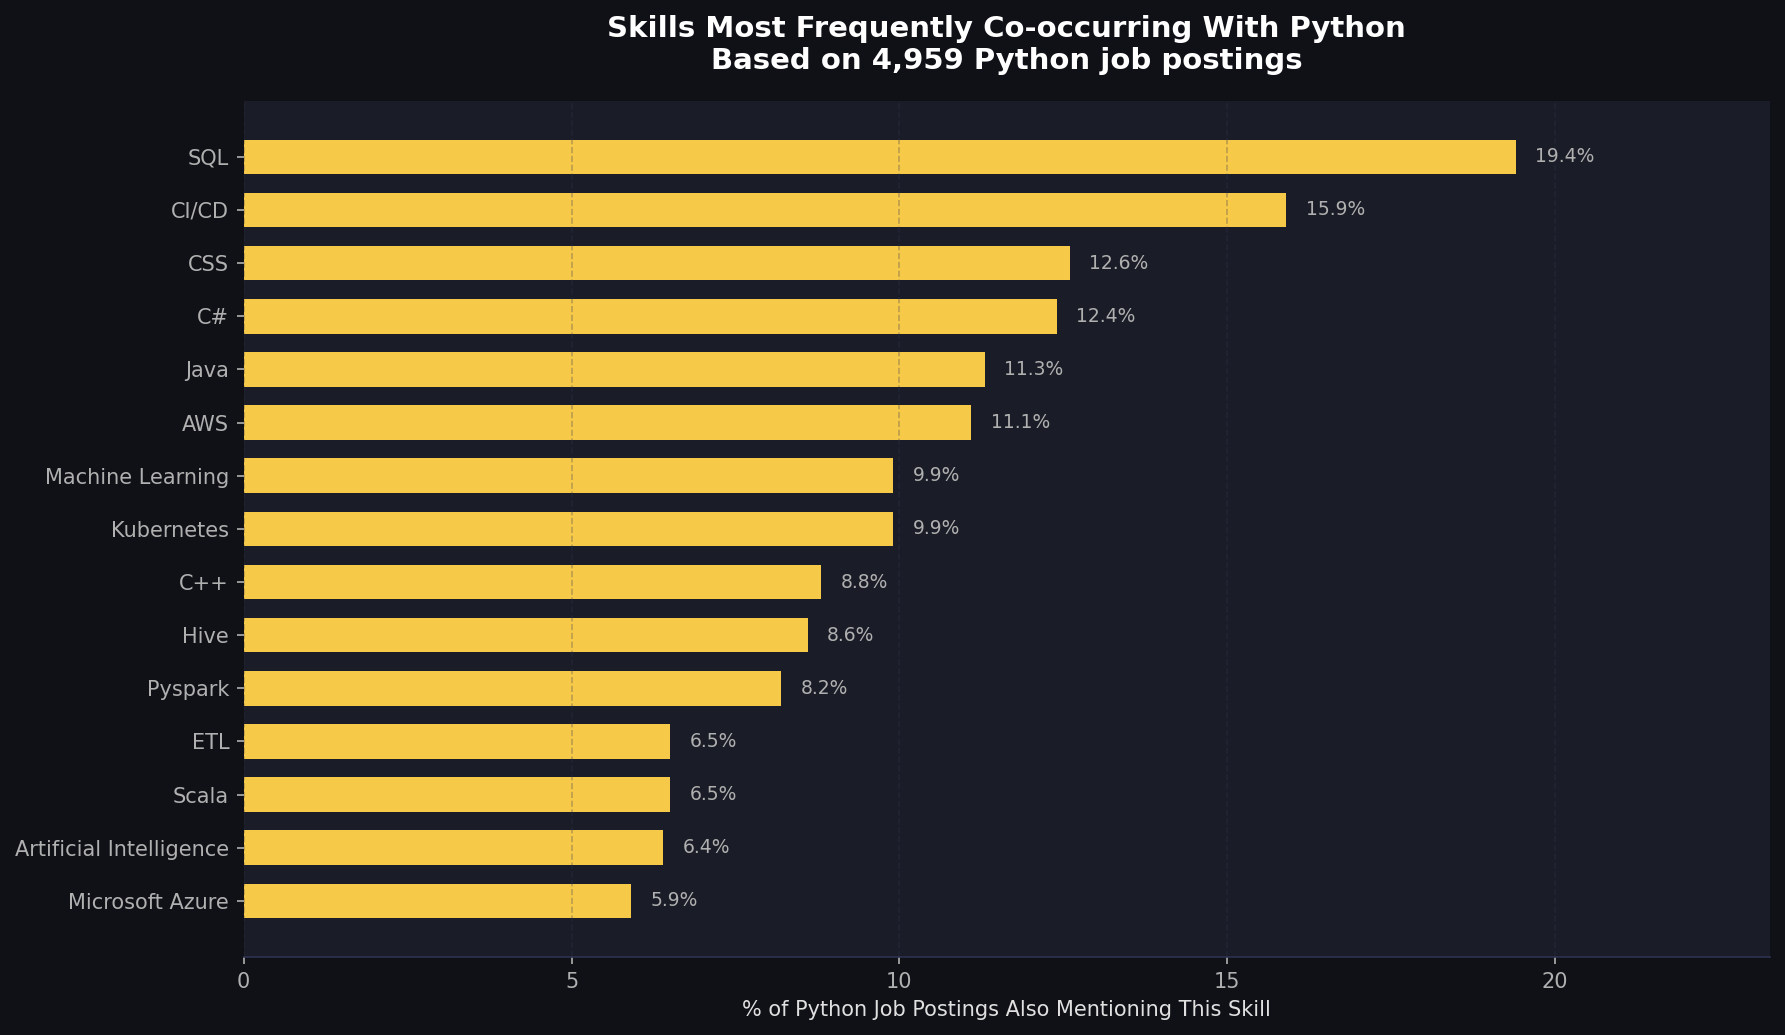

✅ Saved: ../outputs/charts/A3_python_skill_cooccurrence.png


In [6]:
# ── Chart A3: Skills Co-occurrence — What Appears With Python? ─
# Business Question 5: Which skills appear together most often?

python_jobs = df_skills[df_skills['skill'] == 'Python']['jobId'].unique()

co_skills = (df_skills[
    df_skills['jobId'].isin(python_jobs) & 
    (df_skills['skill'] != 'Python')
]['skill']
.value_counts()
.head(15)
.reset_index())
co_skills.columns = ['skill', 'count']
co_skills['pct_of_python_jobs'] = (co_skills['count'] / len(python_jobs) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(co_skills['skill'][::-1],
               co_skills['pct_of_python_jobs'][::-1],
               color=COLORS['secondary'],
               edgecolor='none',
               height=0.65)

for bar, pct in zip(bars, co_skills['pct_of_python_jobs'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', ha='left', fontsize=9, color=COLORS['subtext'])

ax.set_xlabel('% of Python Job Postings Also Mentioning This Skill')
ax.set_title('Skills Most Frequently Co-occurring With Python\n'
             f'Based on {len(python_jobs):,} Python job postings',
             pad=15)
ax.set_xlim(0, co_skills['pct_of_python_jobs'].max() * 1.2)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
save_chart('A3_python_skill_cooccurrence.png')

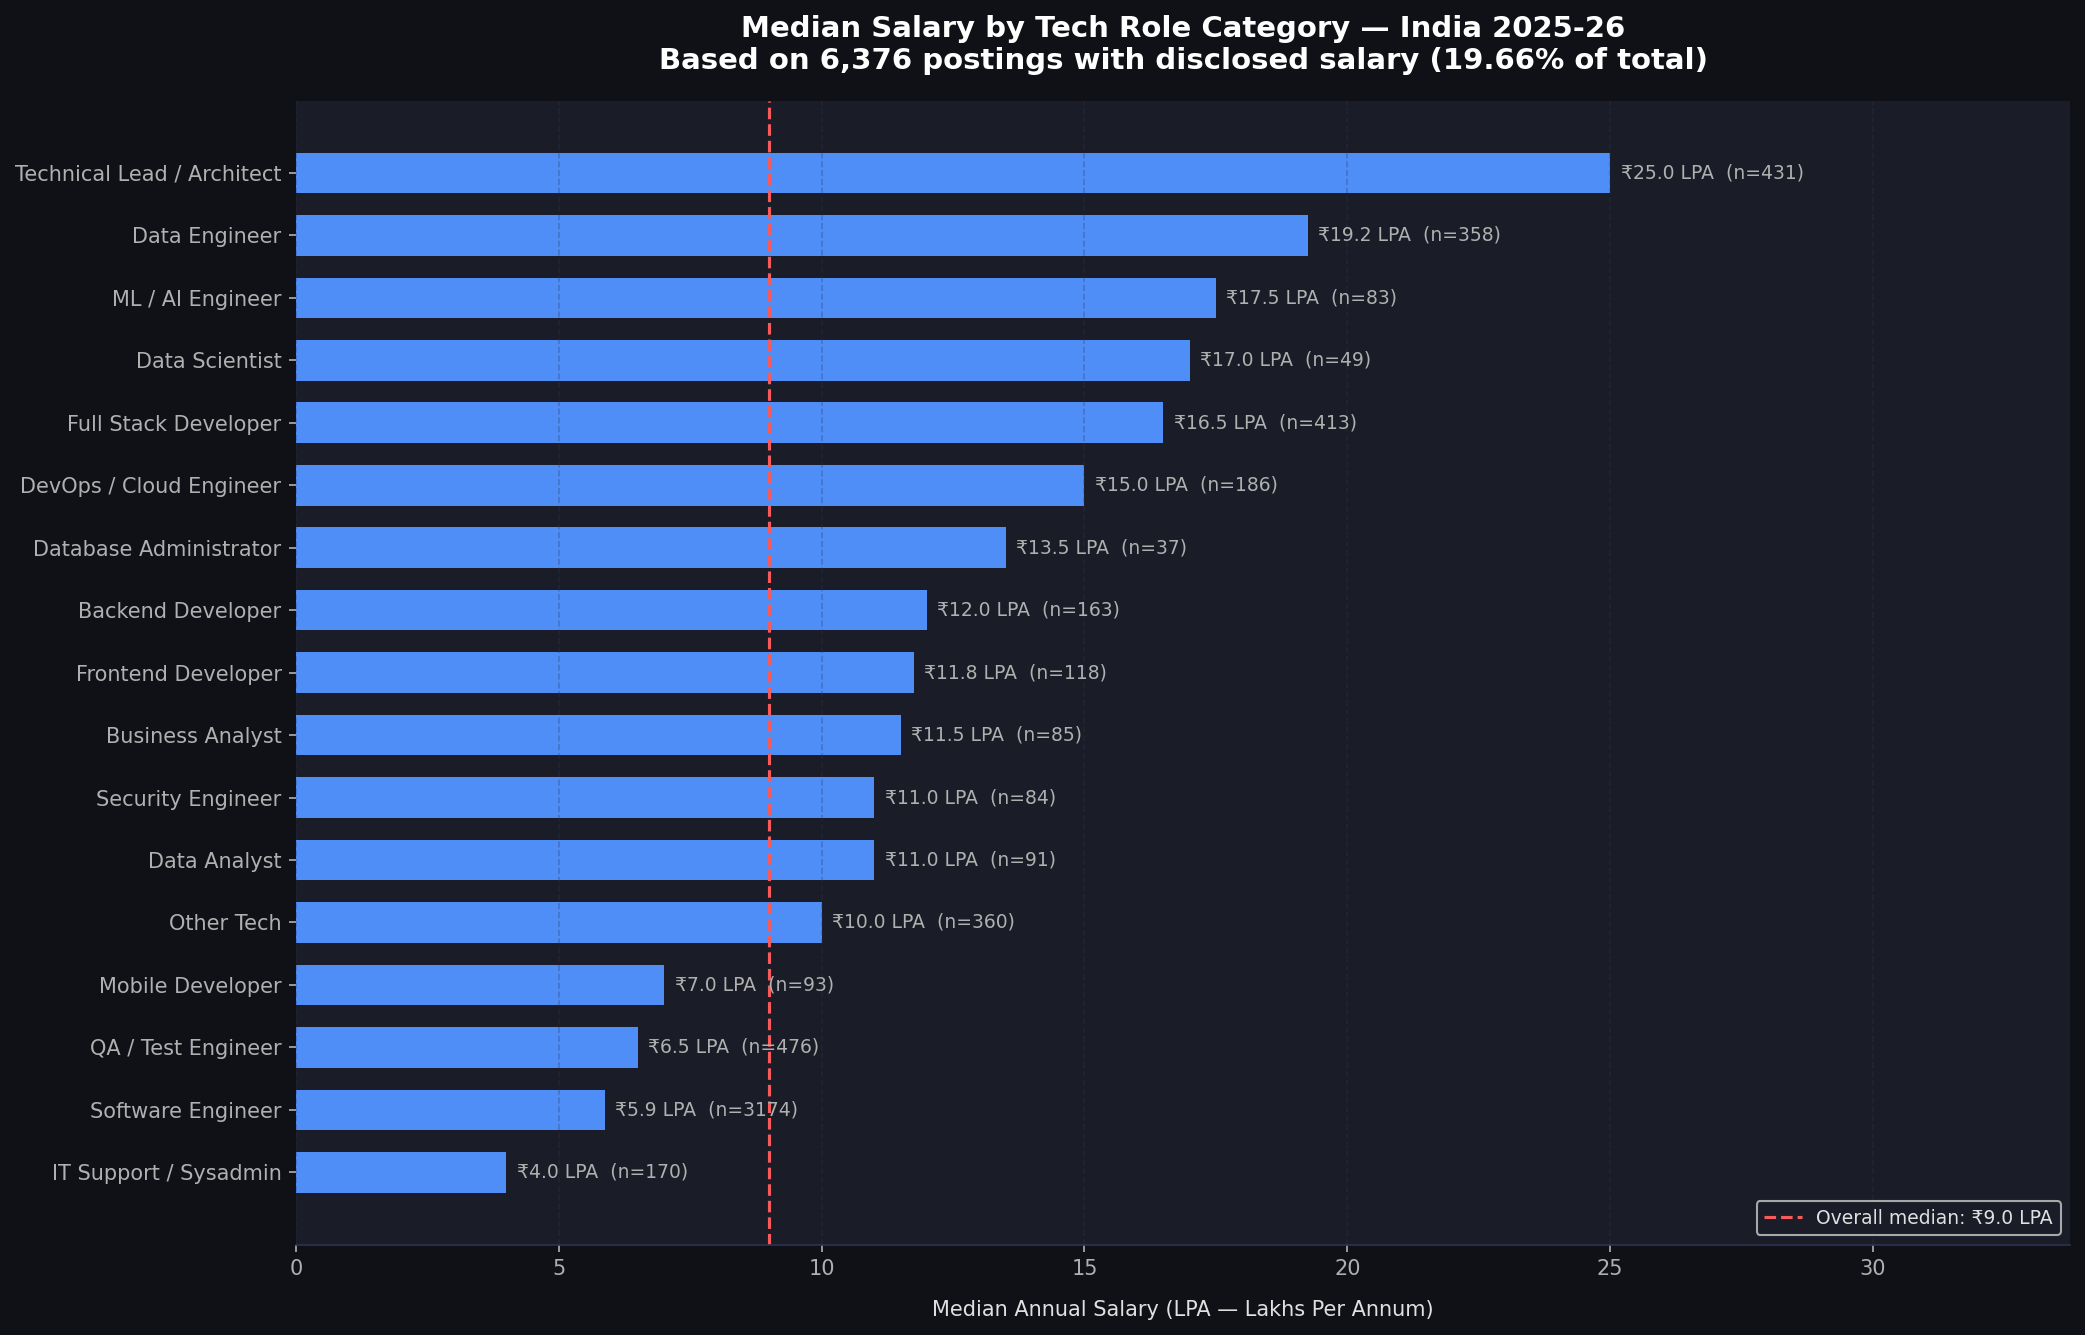

✅ Saved: ../outputs/charts/B1_salary_by_role.png


In [7]:
# ── BLOCK B: SALARY INTELLIGENCE ─────────────────────────────

# ── Chart B1: Salary Distribution by Role Category ───────────
top_roles_salary = (df_salary.groupby('role_category')['salary_lpa']
                    .agg(['median', 'mean', 'count'])
                    .reset_index()
                    .rename(columns={'median': 'median_lpa', 
                                     'mean': 'mean_lpa',
                                     'count': 'n_postings'})
                    .query('n_postings >= 30')  # min 30 postings for statistical reliability
                    .sort_values('median_lpa', ascending=True))

fig, ax = plt.subplots(figsize=(14, 9))

bars = ax.barh(top_roles_salary['role_category'],
               top_roles_salary['median_lpa'],
               color=COLORS['primary'],
               edgecolor='none',
               height=0.65)

# Add median value + sample size labels
for bar, row in zip(bars, top_roles_salary.itertuples()):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'₹{row.median_lpa:.1f} LPA  (n={row.n_postings})',
            va='center', ha='left', fontsize=9, color=COLORS['subtext'])

ax.axvline(df_salary['salary_lpa'].median(), 
           color=COLORS['accent'], 
           linestyle='--', linewidth=1.5,
           label=f'Overall median: ₹{df_salary["salary_lpa"].median():.1f} LPA')

ax.set_xlabel('Median Annual Salary (LPA — Lakhs Per Annum)', labelpad=10)
ax.set_title('Median Salary by Tech Role Category — India 2025-26\n'
             f'Based on {len(df_salary):,} postings with disclosed salary (19.66% of total)',
             pad=15)
ax.set_xlim(0, top_roles_salary['median_lpa'].max() * 1.35)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
save_chart('B1_salary_by_role.png')

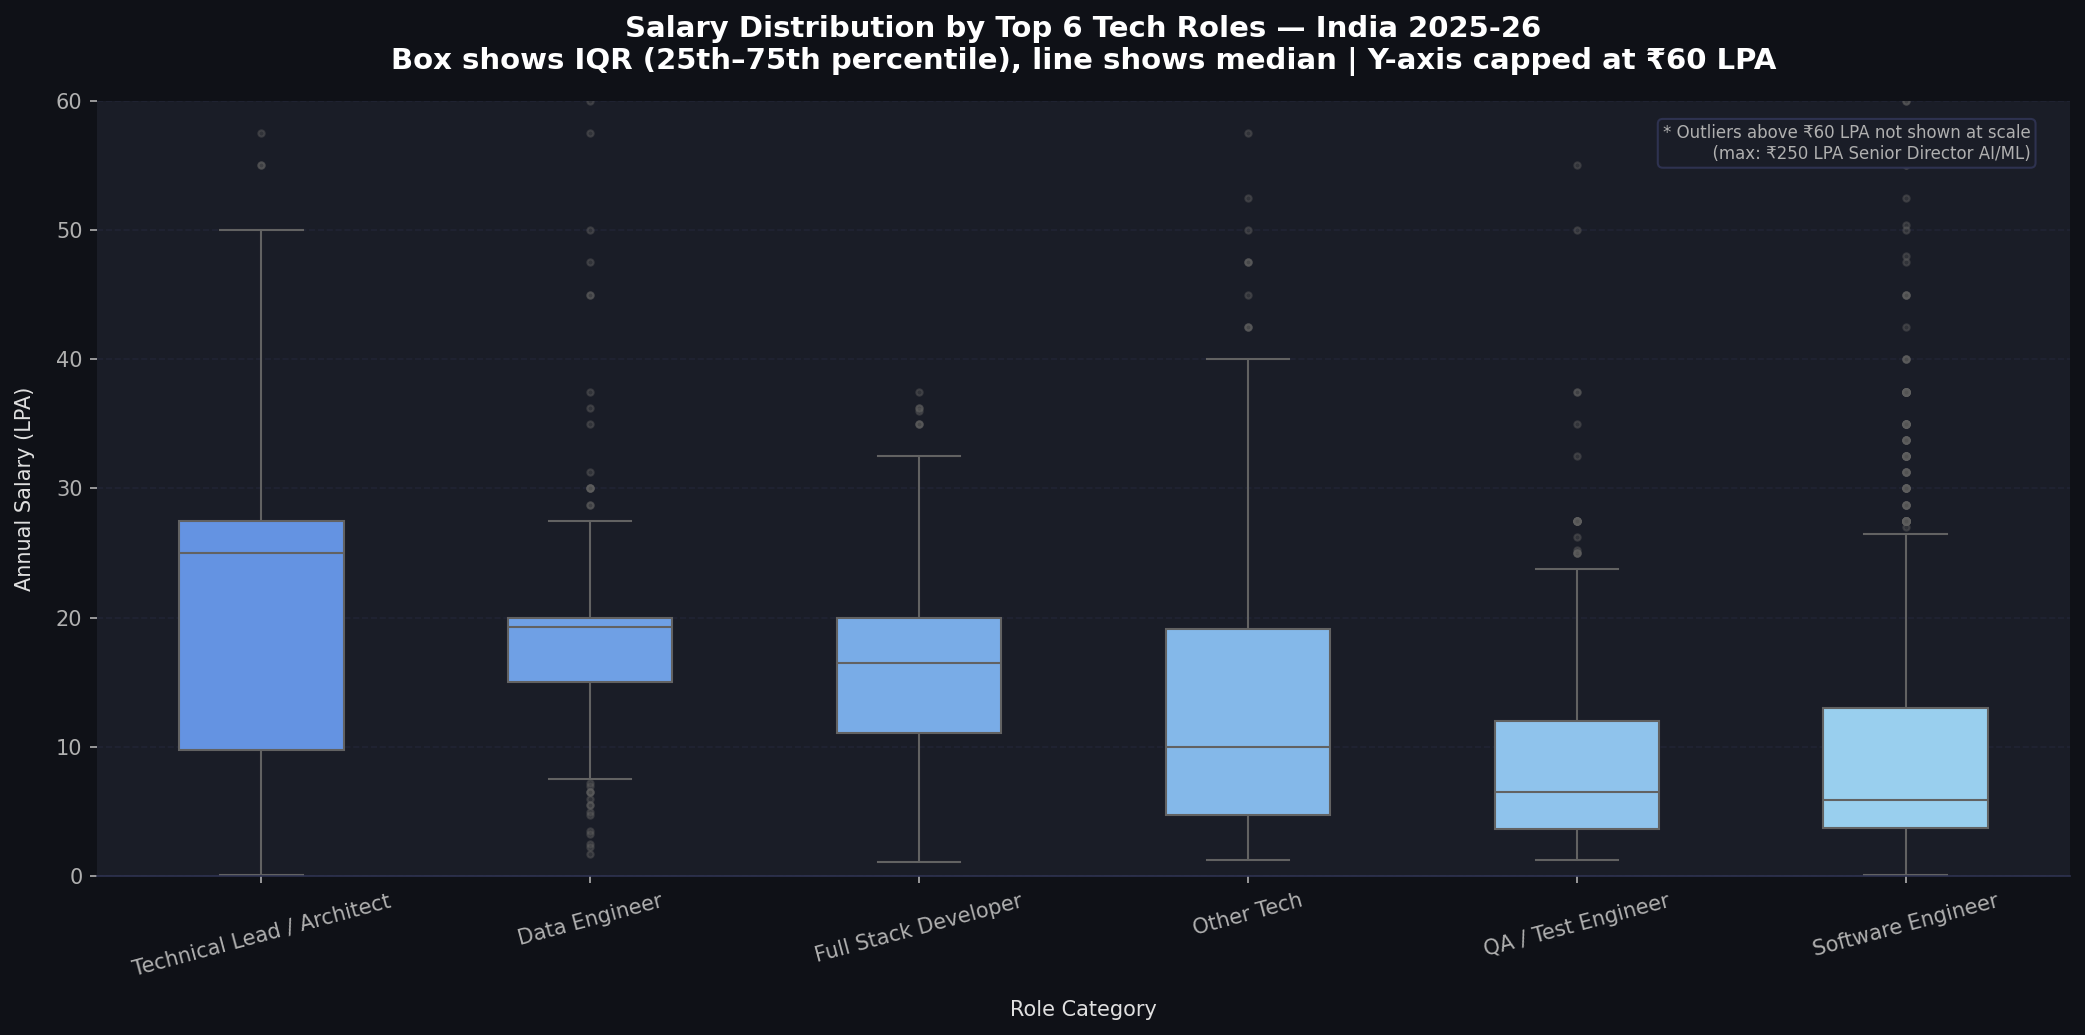

✅ Saved: ../outputs/charts/B2_salary_distribution_boxplot.png


In [8]:
# ── Chart B2 Fixed: Cap Y-axis to show distribution clearly ──
top6_roles = (df_salary.groupby('role_category')['salary_lpa']
              .count()
              .nlargest(6)
              .index.tolist())

df_b2 = df_salary[df_salary['role_category'].isin(top6_roles)].copy()

order = (df_b2.groupby('role_category')['salary_lpa']
         .median()
         .sort_values(ascending=False)
         .index.tolist())

fig, ax = plt.subplots(figsize=(14, 7))

bp = sns.boxplot(data=df_b2,
                 x='role_category',
                 y='salary_lpa',
                 order=order,
                 palette=BAR_PALETTE[:6],
                 width=0.5,
                 flierprops=dict(marker='o', markerfacecolor='#555',
                                 markersize=3, alpha=0.4),
                 ax=ax)

# Cap Y-axis — outliers still shown as dots above the cap
ax.set_ylim(0, 60)
ax.annotate('* Outliers above ₹60 LPA not shown at scale\n'
            '  (max: ₹250 LPA Senior Director AI/ML)',
            xy=(0.98, 0.97), xycoords='axes fraction',
            ha='right', va='top', fontsize=8,
            color=COLORS['subtext'],
            bbox=dict(boxstyle='round,pad=0.3', 
                      facecolor='#1A1D27', edgecolor='#2E3250'))

ax.set_xlabel('Role Category', labelpad=10)
ax.set_ylabel('Annual Salary (LPA)', labelpad=10)
ax.set_title('Salary Distribution by Top 6 Tech Roles — India 2025-26\n'
             'Box shows IQR (25th–75th percentile), line shows median | Y-axis capped at ₹60 LPA',
             pad=15)
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
save_chart('B2_salary_distribution_boxplot.png')

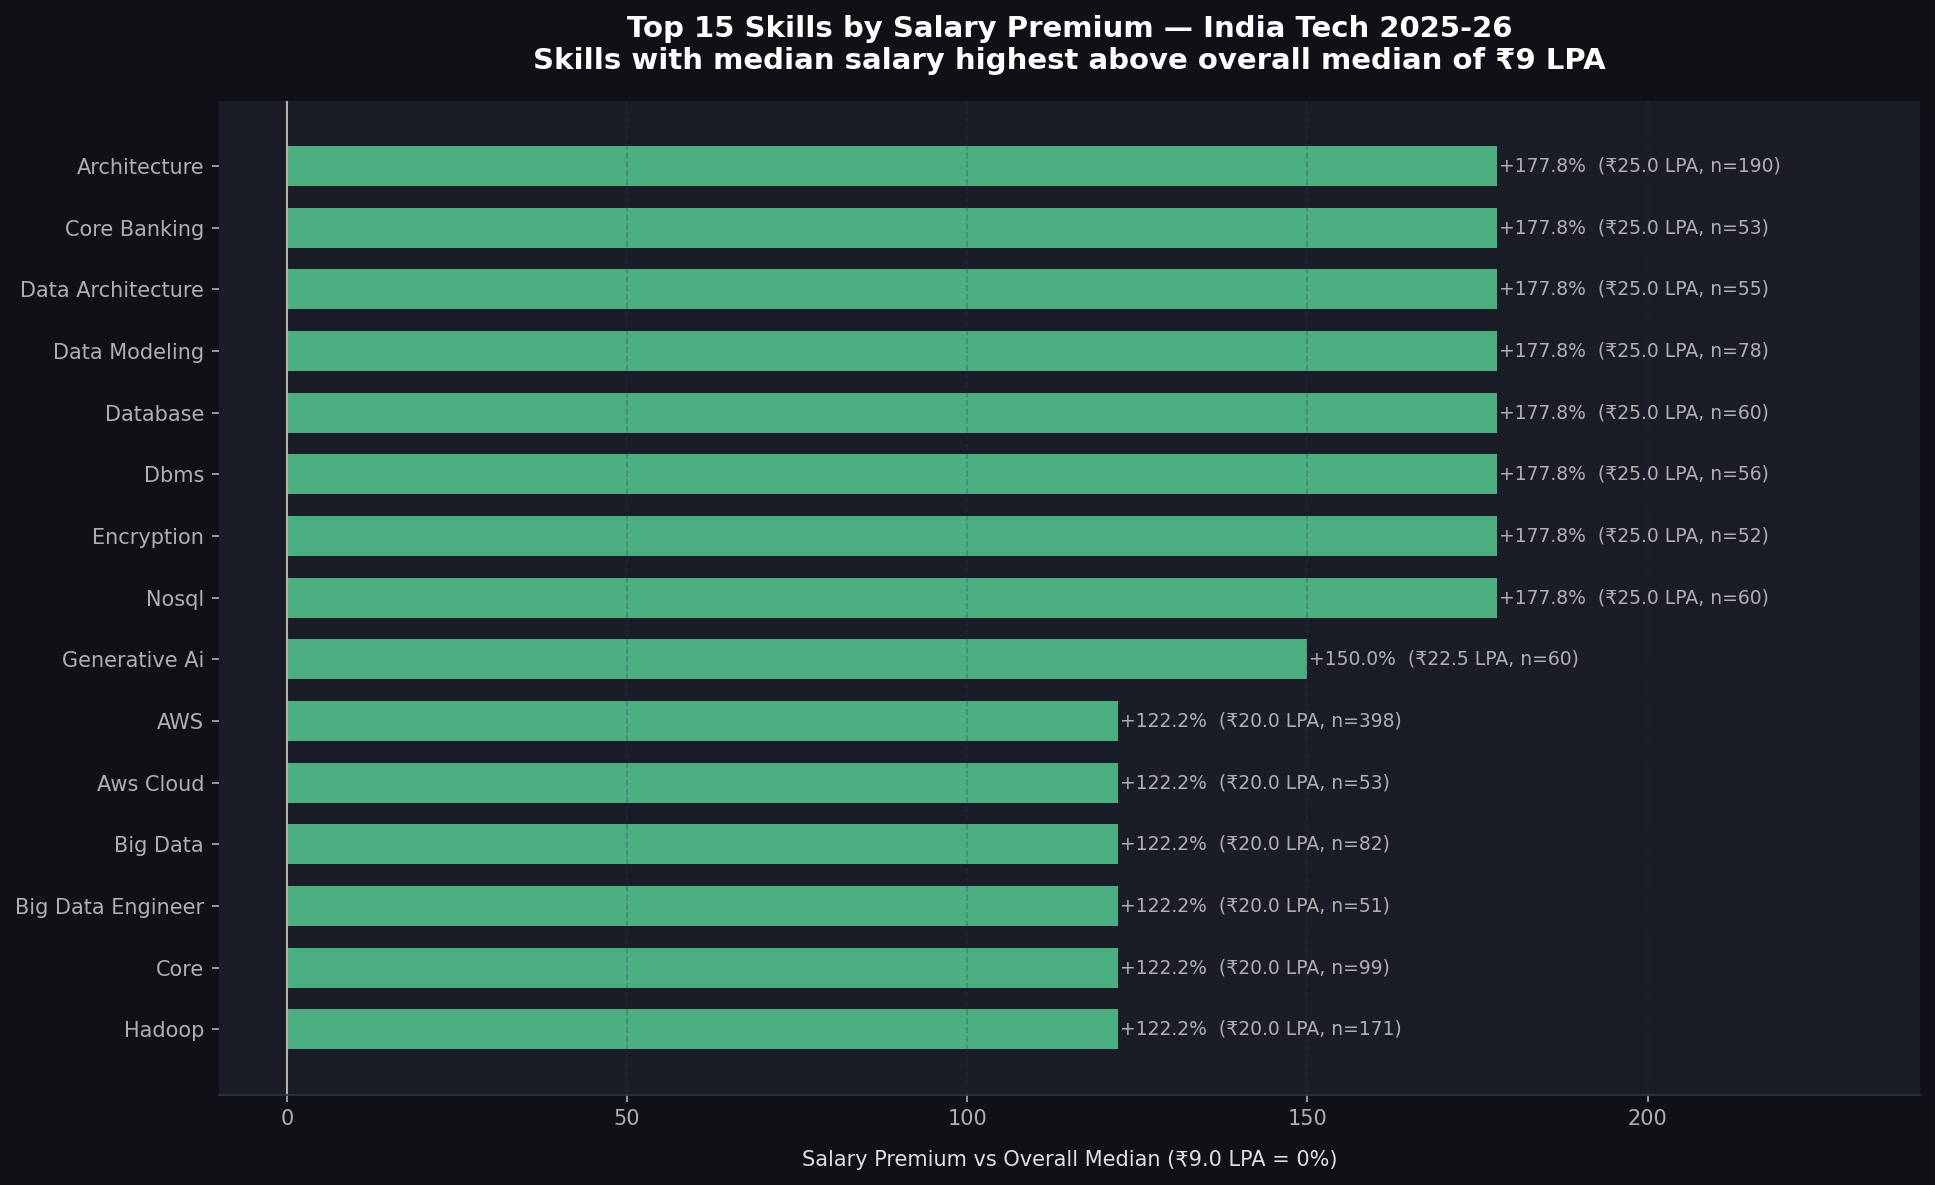

✅ Saved: ../outputs/charts/B3_skill_salary_premium.png


In [ ]:
# Fix 1: Add missing normalizations
additional_normalizations = {
    'Dbms': 'DBMS',
    'Nosql': 'NoSQL',
    'Generative Ai': 'Generative AI',
    'Aws Cloud': 'AWS Cloud',
    'Big Data Engineer': 'Big Data',  # merge with Big Data
    'Core': 'Core Java',             # too generic otherwise
}
df_skills['skill'] = df_skills['skill'].replace(additional_normalizations)

# Fix 2: Exclude skills that are just proxies for the Technical Lead role
# by filtering to skills that appear across AT LEAST 3 different role categories
skill_role_diversity = (df_skills[df_skills['salary_lpa'] > 0]
                        .groupby('skill')['role_category']
                        .nunique()
                        .reset_index()
                        .rename(columns={'role_category': 'n_roles'}))

skill_salary_v2 = (df_skills[df_skills['salary_lpa'] > 0]
                   .groupby('skill')['salary_lpa']
                   .agg(['median', 'count'])
                   .reset_index()
                   .rename(columns={'median': 'median_lpa', 'count': 'n'}))

skill_salary_v2 = skill_salary_v2.merge(skill_role_diversity, on='skill')

# Only skills with 50+ mentions AND appearing in 3+ role categories
skill_salary_v2 = skill_salary_v2[
    (skill_salary_v2['n'] >= 50) & 
    (skill_salary_v2['n_roles'] >= 3)
].copy()

skill_salary_v2['premium_pct'] = (
    (skill_salary_v2['median_lpa'] - overall_median) / overall_median * 100
).round(1)

top_premium_v2 = skill_salary_v2.nlargest(15, 'premium_pct')

fig, ax = plt.subplots(figsize=(13, 8))

colors_v2 = [COLORS['green'] if p > 0 else COLORS['accent']
             for p in top_premium_v2['premium_pct']]

bars = ax.barh(top_premium_v2['skill'][::-1],
               top_premium_v2['premium_pct'][::-1],
               color=colors_v2[::-1],
               edgecolor='none',
               height=0.65)

for bar, row in zip(bars, top_premium_v2[::-1].itertuples()):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'+{row.premium_pct:.1f}%  (₹{row.median_lpa:.1f} LPA, n={row.n})',
            va='center', ha='left', fontsize=9, color=COLORS['subtext'])

ax.axvline(0, color=COLORS['subtext'], linewidth=1)
ax.set_xlabel('Salary Premium vs Overall Median (₹9.0 LPA = 0%)', labelpad=10)
ax.set_title('Top 15 Skills by Salary Premium — India Tech 2025-26\n'
             'Skills appearing in 3+ role categories with 50+ mentions | Cross-role salary signal',
             pad=15)
ax.set_xlim(-10, top_premium_v2['premium_pct'].max() * 1.35)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
save_chart('B3_skill_salary_premium.png')

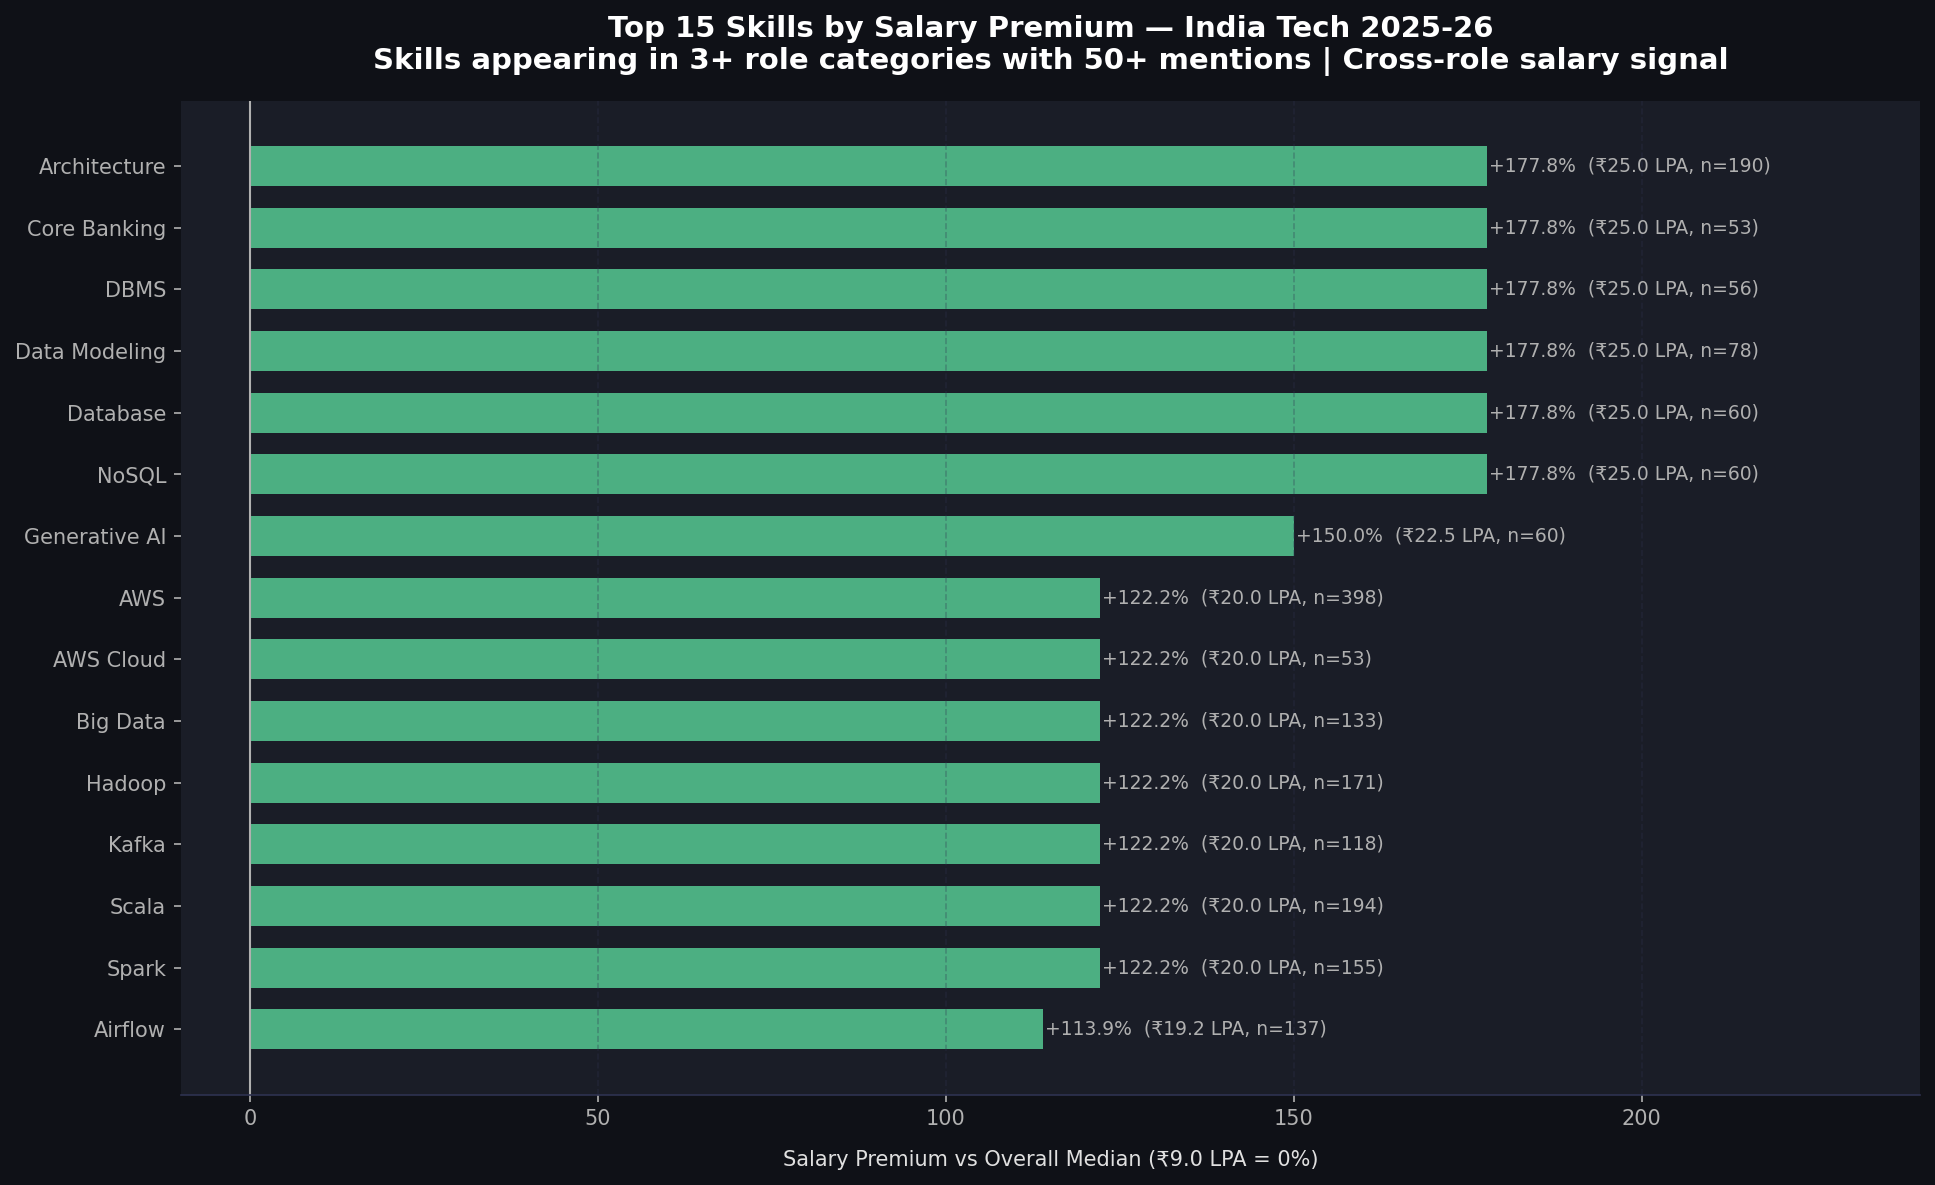

✅ Saved: ../outputs/charts/B3_skill_salary_premium.png


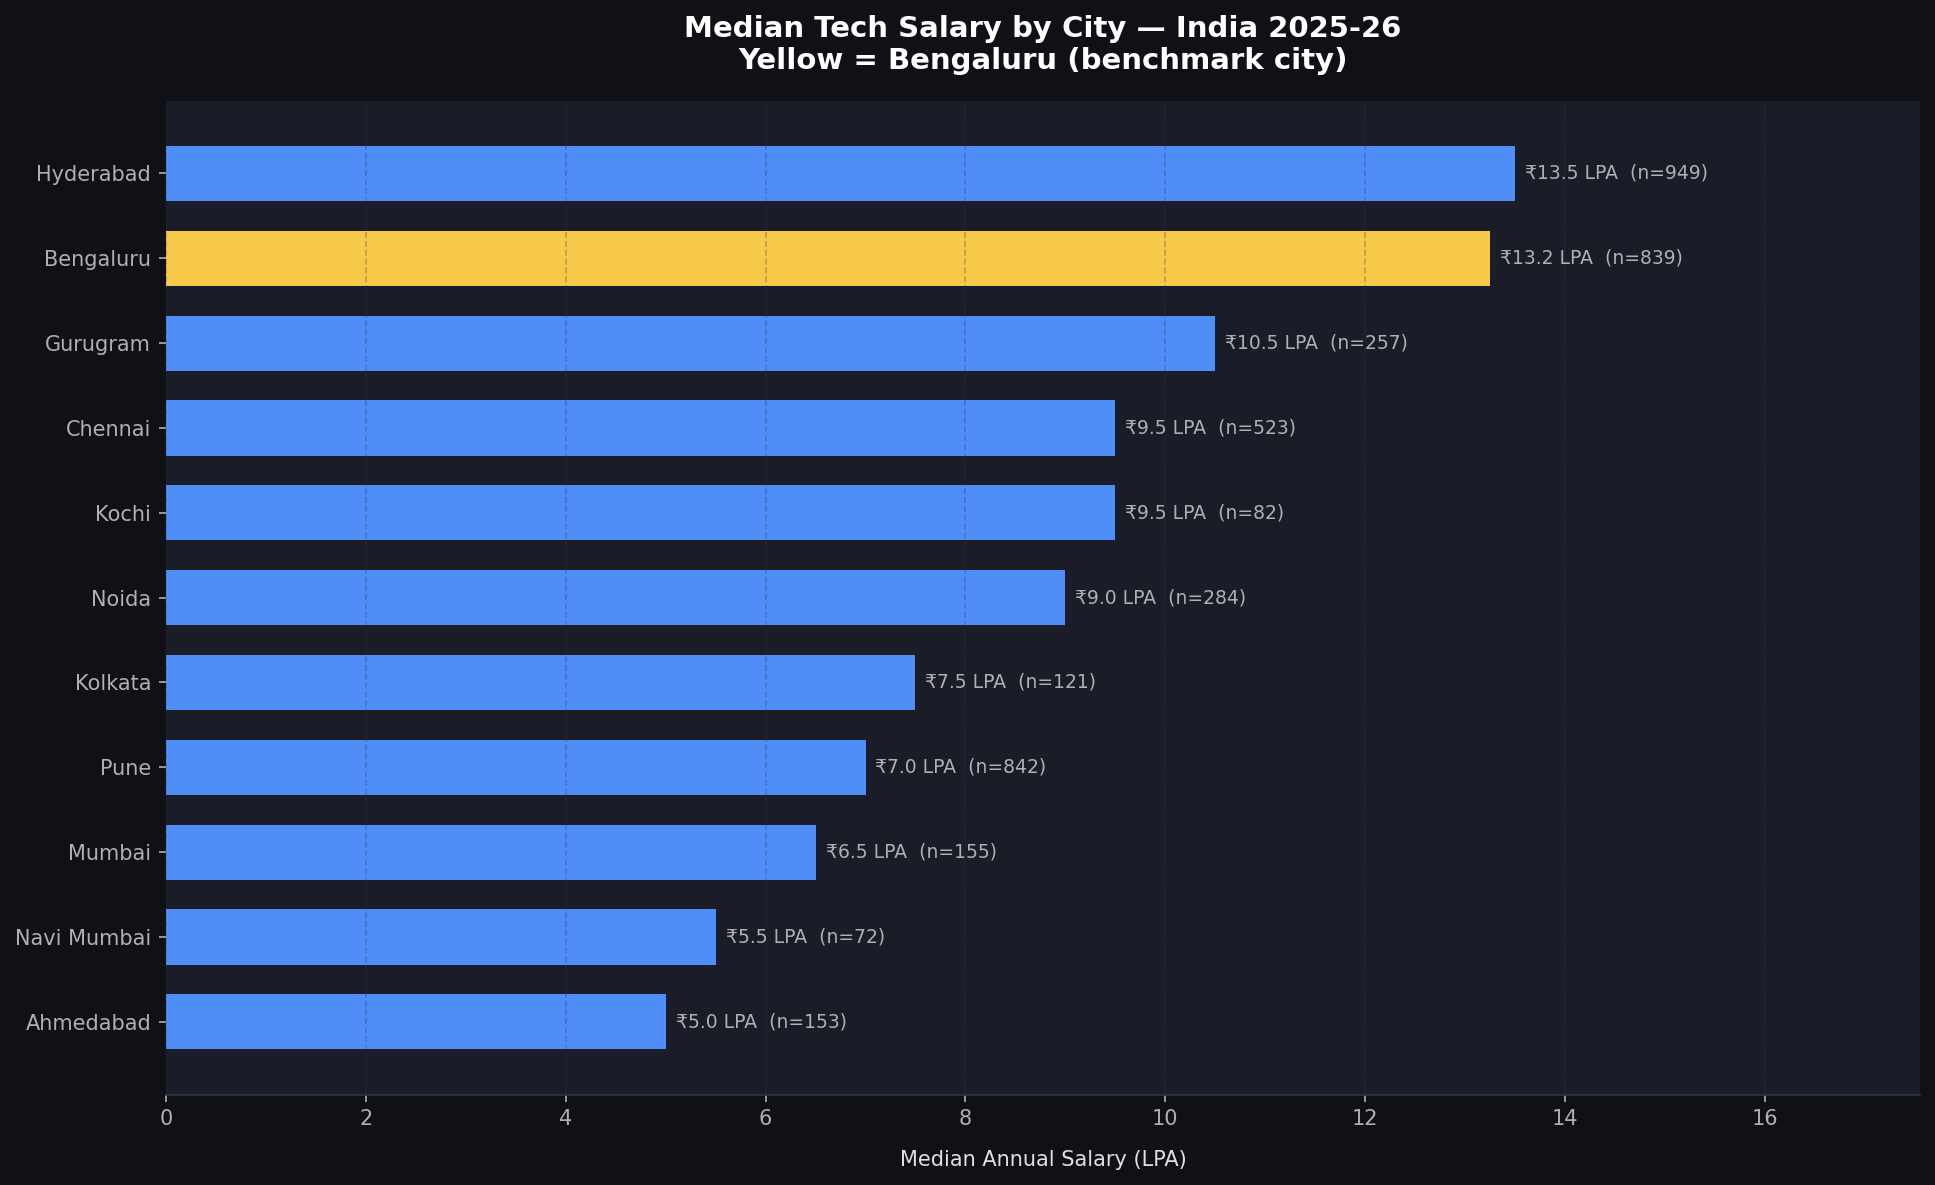

✅ Saved: ../outputs/charts/B4_salary_by_city.png


In [10]:
# ── Chart B4: Salary by City (Top 12 Cities) ─────────────────
top12_cities = (df_salary.groupby('city_tier_group')['salary_lpa']
                .count()
                .nlargest(13)
                .index.tolist())

# Remove "Other Cities" and "Not Specified"
top12_cities = [c for c in top12_cities 
                if c not in ['Other Cities', 'Not Specified']][:12]

city_salary = (df_salary[df_salary['city_tier_group'].isin(top12_cities)]
               .groupby('city_tier_group')['salary_lpa']
               .agg(['median', 'count'])
               .reset_index()
               .rename(columns={'median': 'median_lpa', 'count': 'n'})
               .sort_values('median_lpa', ascending=True))

fig, ax = plt.subplots(figsize=(13, 8))

bar_colors = [COLORS['secondary'] if city == 'Bengaluru' 
              else COLORS['primary'] for city in city_salary['city_tier_group']]

bars = ax.barh(city_salary['city_tier_group'],
               city_salary['median_lpa'],
               color=bar_colors,
               edgecolor='none',
               height=0.65)

for bar, row in zip(bars, city_salary.itertuples()):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            f'₹{row.median_lpa:.1f} LPA  (n={row.n})',
            va='center', ha='left', fontsize=9, color=COLORS['subtext'])

ax.set_xlabel('Median Annual Salary (LPA)', labelpad=10)
ax.set_title('Median Tech Salary by City — India 2025-26\n'
             'Yellow = Bengaluru (benchmark city)',
             pad=15)
ax.set_xlim(0, city_salary['median_lpa'].max() * 1.3)
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right', 'left']].set_visible(False)

plt.tight_layout()
save_chart('B4_salary_by_city.png')